# **Project**
**"What is the early-warning signal for student dropout?"**

**Preparing the data**

In [2]:
#importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#loading the data
df = pd.read_csv("upv_dropout_workshop.csv")

print(df.head())

     student_id admission_pathway  entry_grade  degree_preference dedication  \
0  0002ccc8623e               BMA        7.136                1.0  Full-time   
1  00075bbc7af3               NCA          NaN                NaN  Full-time   
2  0008337bd791               NAP        8.105                2.0  Full-time   
3  000be0ddb26c               NAP        6.309                6.0  Full-time   
4  000d5aac651d               NAP        6.280                1.0  Full-time   

   highest_year  n_courses  avg_course_grade  credits_enrolled  \
0             3          3              5.60              60.0   
1             4         13              4.05              28.5   
2             3         14              5.24              69.0   
3             1          9              4.29              60.0   
4             2          1              5.30              46.5   

   credits_passed  performance  credits_remaining  lms_events  lms_minutes  \
0            60.0       100.00              

In [3]:
# dropping student_id column as it is not needed for analysis
df.drop(columns=["student_id"], inplace=True)

#counting missing values in each column
print(df.isna().sum())

admission_pathway    5123
entry_grade          5709
degree_preference    5265
dedication              0
highest_year            0
n_courses               0
avg_course_grade     1708
credits_enrolled        0
credits_passed          0
performance          1165
credits_remaining       0
lms_events              0
lms_minutes             0
wifi_days               0
dropout                 0
dtype: int64


In [4]:
#filling missing data with mean values for numeric columns
df = df.fillna(df.mean(numeric_only=True))

#filling remaining missing data with "Unknown" for categorical columns
df = df.fillna("Unknown")

print(df.isna().sum())

admission_pathway    0
entry_grade          0
degree_preference    0
dedication           0
highest_year         0
n_courses            0
avg_course_grade     0
credits_enrolled     0
credits_passed       0
performance          0
credits_remaining    0
lms_events           0
lms_minutes          0
wifi_days            0
dropout              0
dtype: int64


In [5]:
#encoding categorical variables using one-hot encoding
df_encoded = pd.get_dummies(df, columns=['admission_pathway', 'dedication'], dtype=int)

print(df_encoded.head())

   entry_grade  degree_preference  highest_year  n_courses  avg_course_grade  \
0     7.136000           1.000000             3          3              5.60   
1     7.430263           1.710724             4         13              4.05   
2     8.105000           2.000000             3         14              5.24   
3     6.309000           6.000000             1          9              4.29   
4     6.280000           1.000000             2          1              5.30   

   credits_enrolled  credits_passed  performance  credits_remaining  \
0              60.0            60.0       100.00              114.0   
1              28.5             0.0         0.00               28.5   
2              69.0            55.5        80.43               81.0   
3              60.0            19.5        32.50              220.5   
4              46.5            31.5        67.74              135.0   

   lms_events  ...  admission_pathway_NCF  admission_pathway_NIE  \
0         234  ...      

**Making the analysis**

First, lets get an overview of correlations of all aspects with `dropout`.

In [6]:
corr=df_encoded.corr()["dropout"].sort_values(ascending=False).drop("dropout")

print(corr)

dedication_Part-time         0.093341
admission_pathway_NCF        0.074923
credits_remaining            0.055522
admission_pathway_NCA        0.040916
admission_pathway_NAI        0.040222
admission_pathway_Unknown    0.039608
degree_preference            0.036631
admission_pathway_NIE        0.016223
admission_pathway_NTE        0.009416
admission_pathway_NSA        0.007822
admission_pathway_NLE        0.007048
admission_pathway_NRO        0.005998
admission_pathway_NSC        0.005721
admission_pathway_ANT       -0.001966
admission_pathway_BMA       -0.003239
n_courses                   -0.037984
admission_pathway_NAP       -0.062397
entry_grade                 -0.083643
wifi_days                   -0.086185
lms_events                  -0.092776
dedication_Full-time        -0.093341
highest_year                -0.101659
lms_minutes                 -0.102649
credits_enrolled            -0.123311
avg_course_grade            -0.215144
credits_passed              -0.230987
performance 

We can see that the main drivers for student dropouts are **performance**, **credits passed/enrolled** and **average course grade** (lowest correlation scores: the worse performance score, less credits passed/enrolled and worse average course grade equals to **more student dropouts**). These will be our **key features**.

Lets divide the data into 3 main categories:

1) **Intake** (`admission_pathway`, `entry_grade`, `degree_preference`, `dedication`)
2) **Engagement** (`lms_events`, `lms_minutes`, `wifi_days`)
3) **Academic Performance** (`highest_year`, `n_courses`, `credits_enrolled`, `credits_remaining`)
4) **Outcome** (`avg_course_grade`, `credits_passed`, `performance`)

Our target: `dropout` (0/1)

Lest analyze our **key features** alongside our different categories.

**1) Performance**

Performance is described as:

$$ \text{Performance} = \frac{\text{Credits passed}}{\text{Credits enrolled}} \times 100\% $$

From the **intake** category, **dedication** seems to be the defining feature for student dropouts.


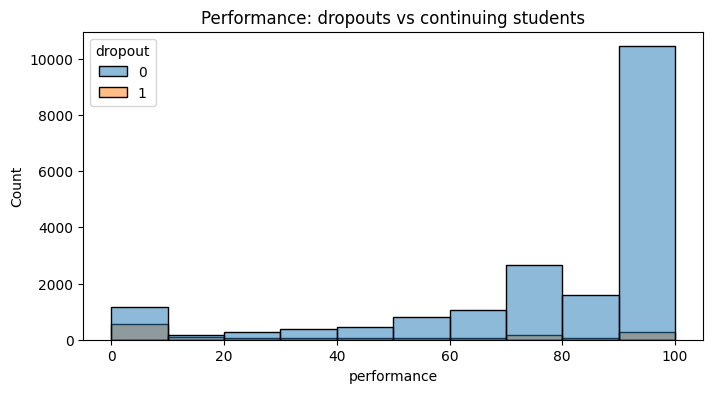

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=df_encoded, x="performance", hue="dropout", bins=10, ax=ax)
ax.set_title("Performance: dropouts vs continuing students")
plt.show()

In [7]:
performance_corr=df_encoded.corr()["performance"].sort_values(ascending=False).drop("performance")

print(performance_corr)

credits_passed               0.722929
avg_course_grade             0.658439
entry_grade                  0.258486
wifi_days                    0.248103
lms_minutes                  0.243798
lms_events                   0.242317
admission_pathway_NAP        0.196925
credits_enrolled             0.193755
dedication_Full-time         0.127546
n_courses                    0.113651
highest_year                 0.025564
admission_pathway_NCF        0.008035
admission_pathway_NSA        0.001009
admission_pathway_NLE       -0.000163
admission_pathway_NSC       -0.001679
admission_pathway_BMA       -0.004961
admission_pathway_ANT       -0.017561
admission_pathway_NRO       -0.022901
admission_pathway_NIE       -0.024836
admission_pathway_NTE       -0.049056
admission_pathway_NCA       -0.054437
degree_preference           -0.114372
admission_pathway_NAI       -0.125623
dedication_Part-time        -0.127546
credits_remaining           -0.133363
admission_pathway_Unknown   -0.151290
dropout     

It makes sense that **credits passed** is the most highley correlated with performance (~0.7), since it has this feature in its formula.

But performance also has **credits enrolled** in its formula, but this feature has a much lower correlation score (~0.2) which makes an intresting point: 

**The amount of credits the student has is far more impactful than the amount of credits the student has left to obtain.**